In [45]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Setup working correctly!")

NumPy version: 2.2.6
Setup working correctly!


In [46]:
# Generate synthetic data for linear regression
# y = 3x + 7 + noise (this is the "true" relationship we want to learn)

np.random.seed(42)

X = 2 * np.random.rand(100, 1)        # 100 data points between 0 and 2
y = 7 + 3 * X + np.random.randn(100, 1) * 0.5  # true slope=3, intercept=7, + noise

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 X values:", X[:5].flatten())
print("First 5 y values:", y[:5].flatten())

X shape: (100, 1)
y shape: (100, 1)
First 5 X values: [0.74908024 1.90142861 1.46398788 1.19731697 0.31203728]
First 5 y values: [ 9.29076425 12.55478216 11.43784404  9.59816645  7.8262759 ]


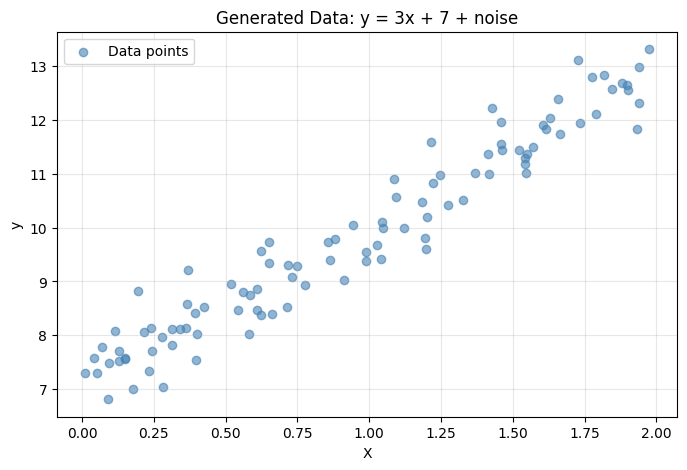

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='steelblue', label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data: y = 3x + 7 + noise')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# Initialize b and w separately - same style as Andrew Ng and PyTorch
b = 0.0  # intercept
w = 0.0  # slope

print("Initial b:", b)
print("Initial w:", w)

Initial b: 0.0
Initial w: 0.0


In [49]:
# Prediction function: y = w*X + b
def predict(X, w, b):
    return np.dot(w, X) + b

# Test with initial parameters
y_hat = predict(X, w, b)
print("Prediction with initial parameters (should be all zeros):", y_hat[:3])

Prediction with initial parameters (should be all zeros): [[0.]
 [0.]
 [0.]]


In [50]:
def compute_cost(X,y,w,b):
    m=len(y)
    #f(x) =w.x +b
    f_wb=predict(w,X,b) 
    #Cost Function J ,(1/2m) *summation from i =1 to m (y_predict-y)square, where m is the size of training set
    cost=(1/(2*m))*np.sum((f_wb-y)**2) #numpy implementation
    return cost

In [51]:
initial_cost=compute_cost(X,y,w,b)
print("Cost with initial parameters", initial_cost)

Cost with initial parameters 49.780903259035405


In [52]:
def compute_gradients(X,y,w,b):
    m=len(y)
    y_hat=predict(X,w,b)
    dj_dw=(1/m)*np.sum((y_hat-y)*X)
    dj_db=(1/m)*np.sum(y_hat-y)
    return dj_dw,dj_db
    

In [53]:
dj_dw, dj_db = compute_gradients(X, y, w, b)
print("Gradient dj_dw:", dj_dw)
print("Gradient dj_db:", dj_db)

Gradient dj_dw: -10.245958013723811
Gradient dj_db: -9.820544280185578


In [54]:
def gradient_descent(X,y,w,b,iterations,alpha):
    J_history=[]
    for i in range(iterations):
        dj_dw,dj_db=compute_gradients(X,y,w,b)
        

        w=w-alpha*dj_dw
        b=b-alpha*dj_db
        if i%100==0:
            # print(dj_dw,dj_db)
            J=compute_cost(X,y,w,b)
            J_history.append(J)
    return w,b,J_history

In [55]:
alpha=0.01
iterations=10000
w_final,b_final,J_history=gradient_descent(X,y,w,b,iterations,alpha)
print("learned w_final/slope : " ,w_final)
print("learned b_final/intercept: ",b_final)
print("True w was 3 and true b was 7")

learned w_final/slope :  2.885056788244861
learned b_final/intercept:  7.107547971149966
True w was 3 and true b was 7


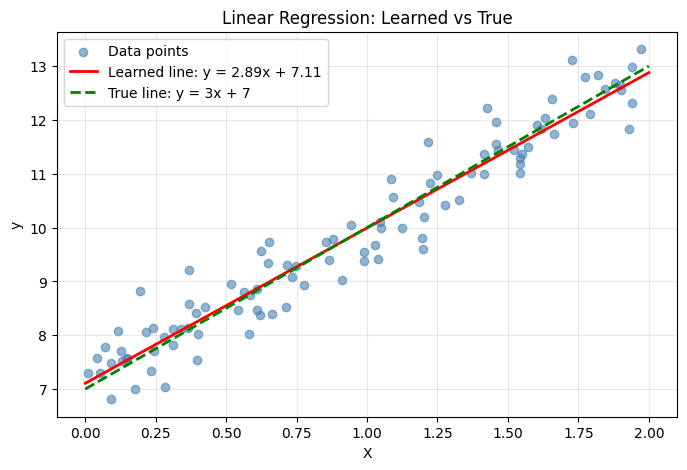

In [56]:
plt.figure(figsize=(8, 5))

# Original data points
plt.scatter(X, y, alpha=0.6, color='steelblue', label='Data points')

# Learned regression line
X_line = np.linspace(0, 2, 100)
y_line = w_final * X_line + b_final
plt.plot(X_line, y_line, color='red', linewidth=2, label=f'Learned line: y = {w_final:.2f}x + {b_final:.2f}')

# True line
y_true_line = 3 * X_line + 7
plt.plot(X_line, y_true_line, color='green', linewidth=2, linestyle='--', label='True line: y = 3x + 7')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression: Learned vs True')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

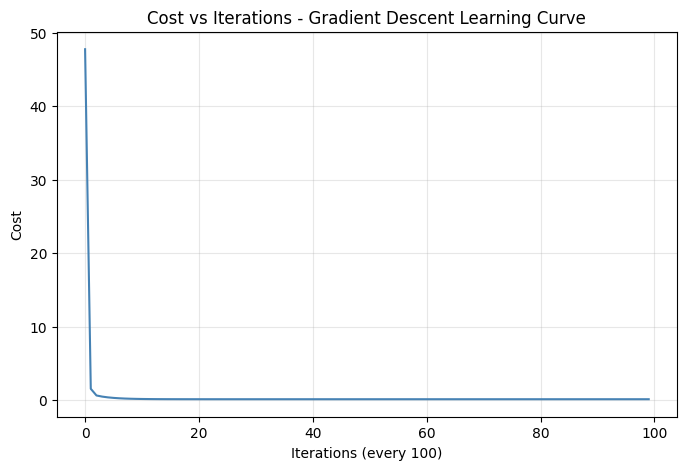

Initial cost: 47.78744108470809
Final cost: 0.10082307049588413


In [57]:
plt.figure(figsize=(8, 5))
plt.plot(J_history, color='steelblue')
plt.xlabel('Iterations (every 100)')
plt.ylabel('Cost')
plt.title('Cost vs Iterations - Gradient Descent Learning Curve')
plt.grid(True, alpha=0.3)
plt.show()

print("Initial cost:", J_history[0])
print("Final cost:", J_history[-1])

In [59]:
print("=" * 45)
print("       LINEAR REGRESSION FROM SCRATCH")
print("=" * 45)
print(f"\nDataset: 100 points, y = 3x + 7 + noise")
print(f"\nModel learned:")
print(f"  Slope (w):     {w_final:.4f}  (true: 3)")
print(f"  Intercept (b): {b_final:.4f}  (true: 7)")
print(f"\nTraining:")
print(f"  Learning rate: 0.01")
print(f"  Iterations:    10000")
print(f"  Initial cost:  {J_history[0]:.4f}")
print(f"  Final cost:    {J_history[-1]:.6f}")
print(f"\nTest predictions:")
test_X = np.array([0.5, 1.0, 1.5])
for x in test_X:
    pred = w_final * x + b_final
    true = 3 * x + 7
    print(f"  X={x} → Predicted: {pred:.3f}, True: {true:.3f}")
print("=" * 45)

       LINEAR REGRESSION FROM SCRATCH

Dataset: 100 points, y = 3x + 7 + noise

Model learned:
  Slope (w):     2.8851  (true: 3)
  Intercept (b): 7.1075  (true: 7)

Training:
  Learning rate: 0.01
  Iterations:    10000
  Initial cost:  47.7874
  Final cost:    0.100823

Test predictions:
  X=0.5 → Predicted: 8.550, True: 8.500
  X=1.0 → Predicted: 9.993, True: 10.000
  X=1.5 → Predicted: 11.435, True: 11.500
